# Homework Assignment 3

**Deadline:** 30 March 2026
<br><br>
**Student names:**: A. Agung Prawira Negara and Nand Van Deun  ← 
<br>
**Total hours spend:** 45 h
<br><br>
**Important Remarks:**
<br>
* **Submitting the homework is a compulsory course component. You will not be able to participate in the exam without submitting your homework solutions before the specified deadline.** 
* Making mistakes or not always being able to completely solve an exercise is fine. The goal is to let you interactively explore the concepts from the lecture and identify common problems/misconceptions. If you could not solve/finish a task, please discuss why using markdown cells.
* If you should have any questions please don't hesitate to ask them. This especially includes any questions on (astro)physical aspects of the exercises. You can use the [discussions section](https://ultra.edu.kuleuven.cloud/ultra/courses/_15842_1/engagement) in our Toledo Ultra course. **Please do not give away your solution to problems to other student groups when using the discussions.**
* Document what you are doing in markdown cells. Adding formulas is a good way to make your implementations in code easier to understand.
* Plots have to follow scientific standards. This includes the requirement of axis labels including measurement units if applicable!
* Indicate how much time you spend in total on this assignment.

**Submission Process:**
<br>
* Groups only need to submit a single notebook, there is no need for individual submissions.
* Rename the notebook as `HomeworkAssignment3_FirstnameLastname1_FirstnameLastname2.ipynb` where you insert your names in the filename.
* Send your notebook to both TAs (Dario Fritzewski: dario.fritzewski@kuleuven.be; Reinhold Willcox: reinhold.willcox@kuleuven.be) using the subject line "**Data Analysis Homework Submission 1**". You can make your notebook file smaller by deleting the outputs before submitting. If the notebook should still be too large for an email, please use [WeTransfer](https://wetransfer.com/).

# Imports

In [32]:
import numpy as np
import scipy as sp
import pandas as pd
rng = np.random.default_rng(seed=42)

import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot

from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize as Cnormalize

import seaborn as sns

from IPython.display import display
from IPython.display import Math
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

import plotly.express as px
import plotly.graph_objs as go
import plotly.io as pio
pio.renderers.default = "notebook"
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)

import lmfit

from uncertainties import ufloat, umath, correlated_values, unumpy

π = np.pi

In [ ]:
%matplotlib inline
from matplotlib import pyplot as plt

# Feel free to change these defaults
plt.rc('font',   size=16)          # controls default text sizes
plt.rc('axes',   titlesize=18)     # fontsize of the axes title
plt.rc('axes',   labelsize=18)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=18)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=18)     # fontsize of the tick labels
plt.rc('legend', fontsize=18)      # legend fontsize
plt.rc('figure', titlesize=18)     # fontsize of the figure title

In [ ]:
from IPython.display import Image

---

## Task 1: Electron microscopy

Transmission electron microscopes (TEMs) are capable of making images with much higher resolution than ordinary optical microscopes that use light. TEM microscopes use an electron beam to probe an ultrathin (< 100 nm) specimen leading to images in which one can distinguish features as small as the size of a single atom, which are showing up as noisy "blobs".

In [ ]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/TEMimage.csv"
image = np.array(pd.read_csv(url, delimiter=' ', header=None))

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
Nrows, Ncols = image.shape
im  = ax.imshow(image, cmap=plt.get_cmap('turbo'), interpolation="nearest", origin='lower', extent=[0,Nrows,0,Ncols])
ax.set_xlabel("x pixel number $N_x$ [px]")
ax.set_ylabel("y pixel number $N_y$ [px]")
plt.show()

The noisy image above shows a part of a lattice structure. The structure consists of 4 identical atoms (faint) on the vertices of a (rotated) square, with an atom of another species (pronounced) in the middle of the square. The structure is embedded in a constant background. You can assume that each of the atoms can be modeled with a spherically-symmetric Gaussian function.

Your tasks for this exercise are the following:

- Perform a non-linear least-squares fit to determine the heights, the (x,y) positions (pixels), and the standard deviations [pixels] of the Gaussian functions, taking into account the constraints of the lattice. Visualize your solution.
- Demonstrate that a model with 5 Gaussians fits the image indeed better than a model with just one Gaussian, despite the extra number of fit parameters.  

**Tip:** if you want to use a regression library that expects 1D arrays instead of the 2D array like the image above, you can use the ravel() function in NumPy to convert the image in a long 1D array. For example:

`image.ravel()`

returns the entire image in a 1D array. The corresponding pixel coordinates can be obtained in a long 1D array with 

```
N=100
x = np.arange(N)
y = np.arange(N)
Xpix, Ypix = np.meshgrid(x, y)
X = Xpix.ravel()
Y = Ypix.ravel()
```

---

Before fitting, we inspect the image numerically to inform our initial 
parameter guesses. The mean intensity serves as the background estimate, 
the maximum intensity indicates the peak of the center atom, and the 
image shape tells us the number of data points.

In [38]:
print(f"Image shape: {image.shape}")
print(f"Min intensity: {image.min():.1f}")
print(f"Max intensity: {image.max():.1f}")
print(f"Mean intensity: {image.mean():.1f}")

Image shape: (100, 100)
Min intensity: 889.5
Max intensity: 1178.2
Mean intensity: 1014.1


We locate the pixel coordinates of the maximum intensity to use as the 
initial guess for the center atom position $(x_c, y_c)$.

In [41]:
#finding the peak position
peak_idx = np.unravel_index(np.argmax(image), image.shape)
print(f"Peak at row={peak_idx[0]}, col={peak_idx[1]}")

Peak at row=60, col=54


`curve_fit` expects 1D input arrays, but the image is a 2D array. We 
therefore create a grid of pixel coordinates (X, Y) and flatten both 
the coordinates and the image intensities to 1D using `ravel()`.

In [42]:
N = 100
x = np.arange(N)
y = np.arange(N)
Xpix, Ypix = np.meshgrid(x, y)
X = Xpix.ravel()
Y = Ypix.ravel()

XY = (X, Y)
Z = image.ravel()

The image is modeled as a sum of 5 spherically symmetric gaussians on a constant background. 
The 4 corner atoms are assumed to share the same height and width 
since they are identical atoms of the same species. Rather than fitting 4 independent positions, we exploit 
the known crystal structure by parameterizing the corners as a rotated 
square with center $(c_x, c_y)$, half-diagonal $r$, and rotation angle 
$\phi$, reducing the number of free parameters from 8 to 3. 
The full model has 11 free parameters.

In [43]:
#model the function
def model_5gaussians(XY, 
                     B,                          # background
                     A_c, x_c, y_c, sig_c,       # center atom
                     A_f, sig_f,                  # corner atoms (shared A and sigma)
                     cx, cy, r, phi):             # square geometry

    X, Y = XY  # unpack pixel coordinates

    # compute 4 corner positions
    angles = np.deg2rad(np.array([45, 135, 225, 315]) + phi)
    x_corners = cx + r * np.cos(angles)
    y_corners = cy + r * np.sin(angles)

    # center atom Gaussian
    Z = B + A_c * np.exp(-((X - x_c)**2 + (Y - y_c)**2) / (2 * sig_c**2))

    # add 4 corner atom Gaussians
    for x0, y0 in zip(x_corners, y_corners):
        Z += A_f * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sig_f**2))

    return Z.ravel()

Initial guesses for all 11 parameters are derived from the image 
statistics computed earlier. The background $B$ is set to the mean 
intensity, and $(x_c, y_c)$ to the coordinates of the peak pixel. 
The center atom width $\sigma_c$ is guessed as ~4 px, consistent 
with a blob a few pixels wide. The corner atom amplitude $A_f$ is 
set to 40 intensity units above background, reflecting their faint 
appearance. The half-diagonal $r$ is estimated as 20 px from visual 
inspection, and $\phi = 0$ since no prior information on the rotation 
is available. These guesses need not be exact, only close enough for 
the optimizer to converge.

In [44]:
#initial guesses
B     = 1014   # background
A_c   = 164    # center atom height above background
x_c   = 54     # center atom x position (col)
y_c   = 60     # center atom y position (row)
sig_c = 4      # center atom width (guess)
A_f   = 40     # corner atom height above background (guess)
sig_f = 4      # corner atom width (guess)
cx    = 54     # square center x (same as center atom)
cy    = 60     # square center y (same as center atom)
r     = 20     # half-diagonal of square (guess)
phi   = 0      # rotation angle (guess)

p0 = [B, A_c, x_c, y_c, sig_c, A_f, sig_f, cx, cy, r, phi]

We fit the model to the image using nonlinear least squares, which minimizes the sum of squared residuals to find the best-fit parameters

In [45]:
from scipy.optimize import curve_fit

popt, pcov = curve_fit(model_5gaussians, XY, Z, p0=p0)

Parameter uncertainties are extracted from the covariance matrix `pcov` 
returned by `curve_fit`, using `correlated_values` which accounts for 
correlations between parameters.

In [47]:
from uncertainties import correlated_values

params = correlated_values(popt, pcov)
param_names = ['B', 'A_c', 'x_c', 'y_c', 'sig_c', 'A_f', 'sig_f', 'cx', 'cy', 'r', 'phi']

for name, param in zip(param_names, params):
    print(f"{name:8s} = {param}")

B        = 1000.2+/-0.4
A_c      = 103.8+/-2.1
x_c      = 56.23+/-0.24
y_c      = 55.90+/-0.24
sig_c    = 12.87+/-0.32
A_f      = 35.4+/-2.2
sig_f    = 5.9+/-0.4
cx       = 56.6+/-0.4
cy       = 55.5+/-0.4
r        = 25.0+/-0.4
phi      = -27.4+/-0.8


We visualize the original image, the fitted model, and the residuals 
(data minus fit). A good fit is indicated by the fitted model 
reproducing the structure of the original image, and residuals showing 
no systematic structure.

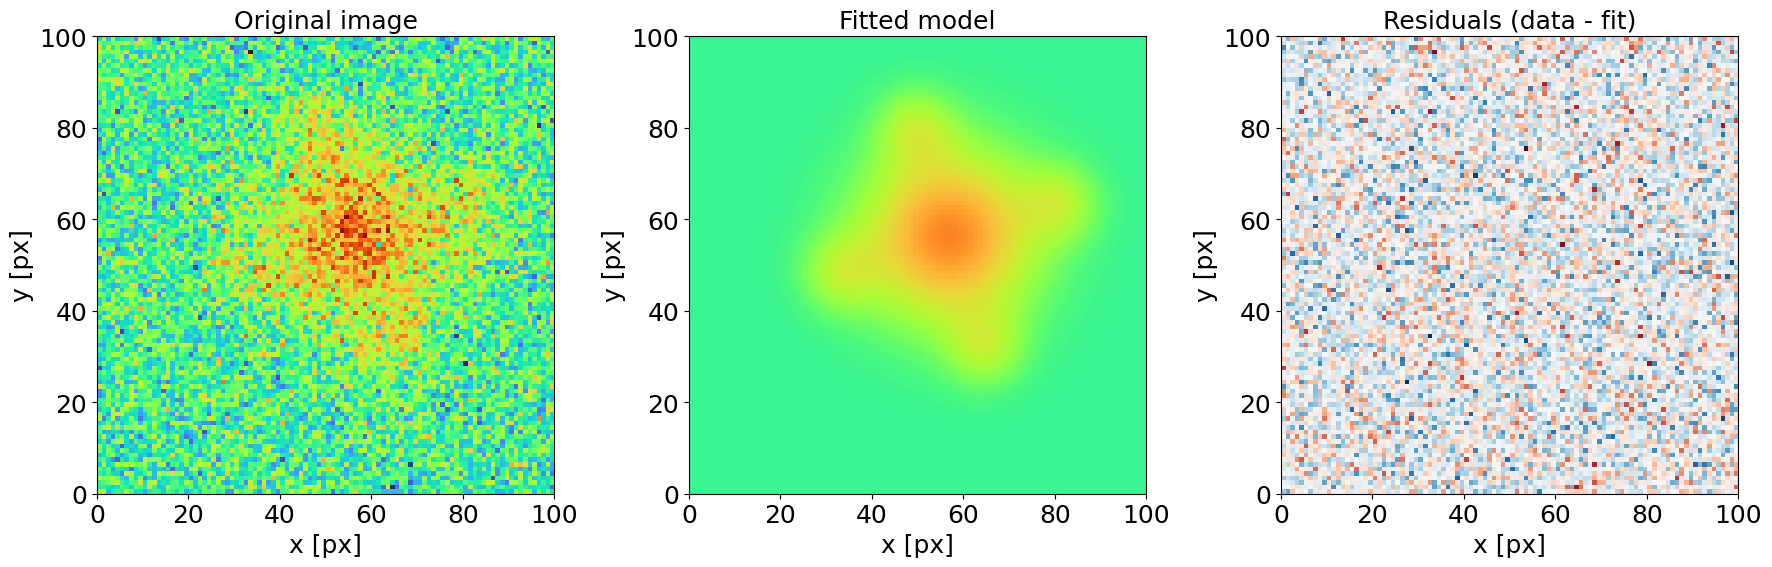

In [50]:
Z_fit = model_5gaussians(XY, *popt).reshape(100, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

vmin = image.min()
vmax = image.max()

axes[0].imshow(image, cmap='turbo', origin='lower', 
               extent=[0,100,0,100], vmin=vmin, vmax=vmax)
axes[0].set_title('Original image')
axes[0].set_xlabel('x [px]')
axes[0].set_ylabel('y [px]')

axes[1].imshow(Z_fit, cmap='turbo', origin='lower', 
               extent=[0,100,0,100], vmin=vmin, vmax=vmax)
axes[1].set_title('Fitted model')
axes[1].set_xlabel('x [px]')
axes[1].set_ylabel('y [px]')

axes[2].imshow(image - Z_fit, cmap='RdBu', origin='lower', extent=[0,100,0,100])
axes[2].set_title('Residuals (data - fit)')
axes[2].set_xlabel('x [px]')
axes[2].set_ylabel('y [px]')

plt.tight_layout()
plt.show()

To verify that ordinary least squares is justified, we inspect the 
distribution of the residuals. If the noise is Gaussian, the residual 
histogram should follow a normal distribution centered on zero.

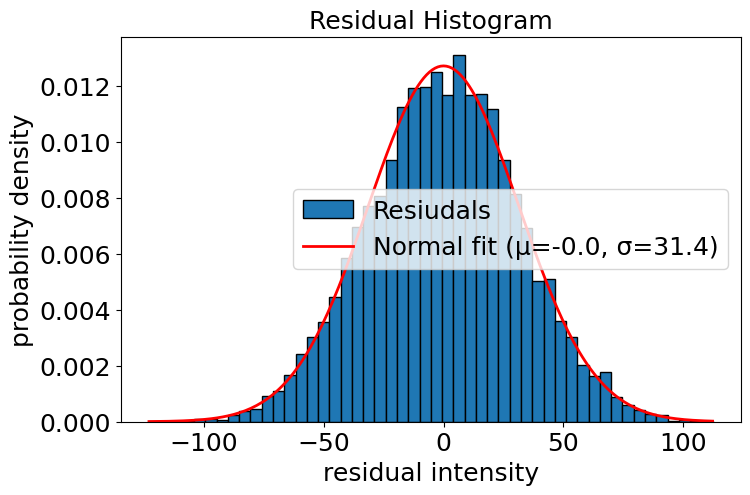

In [60]:
from scipy.stats import norm
residuals = image.ravel() - Z_fit.ravel()
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(residuals, bins=50, edgecolor = 'black', 
       density=True, label="Resiudals")

#fit gaussian to the residuals and overlay it
mu, std = norm.fit(residuals)
x_range = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(x_range, norm.pdf(x_range, mu, std), 'r-', lw=2, label=f'Normal fit (μ={mu:.1f}, σ={std:.1f})')

ax.set_xlabel("residual intensity")
ax.set_ylabel("probability density")
ax.set_title("Residual Histogram")
plt.legend()
plt.show()

To compare models, we first compute the residual sum of squares (RSS) 
for the 5-Gaussian fit, which serves as an ingredient for the AIC and BIC.

In [62]:
RSS_5g = np.sum(residuals**2)
print(f"RSS (5 Gaussians) = {RSS_5g:.2f}")

RSS (5 Gaussians) = 9860431.43


As a baseline for comparison, we fit a simpler model with just one 
Gaussian on a constant background. Demonstrating that the 5-Gaussian 
model is better requires a reference to compare against.

In [63]:
def model_1gaussian(XY, B, A_c, x_c, y_c, sig_c):
    X, Y = XY
    Z = B + A_c * np.exp(-((X - x_c)**2 + (Y - y_c)**2) / (2 * sig_c**2))
    return Z.ravel()

In [64]:
p0_1g = [1014, 164, 54, 60, 4]

popt_1g, pcov_1g = curve_fit(model_1gaussian, XY, Z, p0=p0_1g)

In [65]:
Z_fit_1g = model_1gaussian(XY, *popt_1g).reshape(100, 100)
residuals_1g = image.ravel() - Z_fit_1g.ravel()
RSS_1g = np.sum(residuals_1g**2)

We compute AIC and BIC for both models. Both criteria penalize model 
complexity but by different amounts, BIC penalizes extra parameters 
more harshly than AIC for large datasets. A lower value indicates a 
better balance between fit quality and model complexity.

In [66]:
n = 100 * 100  # number of data points

k_5g = 11  # parameters in 5-Gaussian model
k_1g = 5   # parameters in 1-Gaussian model

# log-likelihood approximation
logL_5g = -n/2 * np.log(RSS_5g / n)
logL_1g = -n/2 * np.log(RSS_1g / n)

# AIC
AIC_5g = 2*k_5g - 2*logL_5g
AIC_1g = 2*k_1g - 2*logL_1g

# BIC
BIC_5g = k_5g*np.log(n) - 2*logL_5g
BIC_1g = k_1g*np.log(n) - 2*logL_1g

print(f"{'Model':<15} {'k':>4} {'RSS':>14} {'AIC':>12} {'BIC':>12}")
print(f"{'1 Gaussian':<15} {k_1g:>4} {RSS_1g:>14.2f} {AIC_1g:>12.2f} {BIC_1g:>12.2f}")
print(f"{'5 Gaussians':<15} {k_5g:>4} {RSS_5g:>14.2f} {AIC_5g:>12.2f} {BIC_5g:>12.2f}")

Model              k            RSS          AIC          BIC
1 Gaussian         5    10137091.40     69223.71     69259.76
5 Gaussians       11     9860431.43     68959.00     69038.31


# Conclusion
We performed a nonlinear least-squares fit of 5 Gaussians to the TEM 
image, successfully locating the center atom at $(x_c, y_c) = (56.2 
\pm 0.2, 55.9 \pm 0.2)$ px and the 4 corner atoms arranged in a 
rotated square with half-diagonal $r = 25.0 \pm 0.4$ px and rotation 
angle $\phi = -27.4 \pm 0.8$ degrees. The fit is supported by the 
residual image showing no systematic structure and a residual histogram 
consistent with a normal distribution. Model comparison via AIC and BIC 
confirms that the 5-Gaussian model is strongly preferred over a simpler 
1-Gaussian model ($\Delta$AIC = 264, $\Delta$BIC = 221, both well above 
the threshold of 10), demonstrating that all 5 atoms are genuine 
features in the image.

---

## Task 2: Elliptical galaxies

Elliptical galaxies are galaxies that have an ellipsoidal shape and a smooth featureless appearance. A famous example is the galaxy NGC4472 also known as M49, which is located in the constellation of Virgo, about 56 million lightyears away from us. The galaxy is believed to host a massive black hole of more than 500 million solar masses. 

In [ ]:
Image(url="https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/M49.jpeg", width=700)

The image above shows the elliptical galaxy NGC4472. Credit: David W. Hogg, Michael R. Blanton, and the Sloan Digital Sky Survey Collaboration.

NGC4472 is part of a cluster of galaxies called the Virgo cluster, which contains more than 1300 galaxies:

In [ ]:
Image(url="https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/Virgo_cluster.png", width=700)

The image above shows the Virgo cluster, which was edited so that no foreground stars are visible. Credit: Pablo Carlos Budassi.

As the image of NGC4472 clearly shows, the local surface intensity $I$ of the galaxy clearly decreases from the core to the edge of the galaxy. One of the first attempts to model this behavior was the intensity profile proposed by Hubble in 1930):

$$ I(r) = I_0 \ (1 + r/r_e)^{-2} $$

Here $I(r)$ is the intensity as a function of angular distance $r$, and $I_0$ and $r_e$ are free (fit) parameters. Another model was proposed by Vaucouleurs in 1948:

$$ I(r) = I_0 \ e^{-k [(r/r_e)^{1/4} - 1]} $$

with $k=7.669$, and yet another profile by Sérsic (1968):

$$ I(r) = I_0 \ 10^{-b_n [(r/r_e)^{1/n} -1]} $$

The parameter $r_e$ and in the case of Sérsic's profile also the (real-valued) parameter $n$ can be linked to the structure of the galaxy. In Sérsic's law, $b_n = 0.868 n - 0.142$ for $n\in[0.5, 16.5]$.  

The datasets for this exercise are borrowed from Feigelson & Babu (2012) who in turn extracted it from Kormendy et al. (2009). They contain the observed surface brightness profile of three elliptical galaxies: NGC4472, NGC4551, NGC4406. In practice, not the intensity $I(r)$ itself can be measured, but the surface brightness

$$\mu(r) = \mu_0 - 2.5 \log_{10} I(r) $$

which is expressed in magnitude per square arcsec. The exact unit is not really relevant for this exercise.

In [ ]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/NGC4472_profile.csv"
ngc4472 = pd.read_csv(url)

In [ ]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/NGC4551_profile.csv"
ngc4551 = pd.read_csv(url)

In [ ]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/NGC4406_profile.csv"
ngc4406 = pd.read_csv(url)

In [ ]:
ngc4472.head()

The columns in the datasets are:
- **radius**: the radial distance $r$ on the sky from the core of the galaxy [arcsec]
- **surf_mag**: the surface brightness $\mu(r)$ of the galaxy  [mag/arcsec$^2$]

The parameter $\mu_0=26$ for NGC4472 and NGC4451, and $\mu_0= 32$ for NGC4406. 

Your tasks for this exercise are the following:
- Fit the three models mentioned above to these three galaxy datasets. The relevant fit parameters are $I_0$, $r_e$ and $n$.
- Use both the Akaike as well as the Bayesian information criterion to determine which model should be preferred. Quantify how much you prefer one model above the other. Compare the two approaches.
- Diagnose your regression, and verify whether using ordinary non-linear least-squares is indeed justified. If you see something "anomalous" can you speculate what the reason could be?
- Determine $2\sigma$ individual confidence intervals for the parameters $r_e$ and $n$.
- For NGC4472, determine a $2\sigma$ joint confidence interval of $r_e$ and $n$ and visualize it on a plot together with contours of the cost function $S(\mathbf{\theta})$.
- Again for NGC4472, use bootstrapping to determine individual confidence intervals for the parameters $r_e$ and $n$. Think about the best bootstrap sampling method.

In [12]:
Mu1 = 26
Mu2 = 26
Mu3 = 32
I1 = 10**((Mu1-ngc4472['surf_mag'])/2.5)
r1 = ngc4472['radius']
I2 = 10**((Mu2-ngc4551['surf_mag'])/2.5)
r2 = ngc4551['radius']
I3 = 10**((Mu3-ngc4406['surf_mag'])/2.5)
r3 = ngc4406['radius']

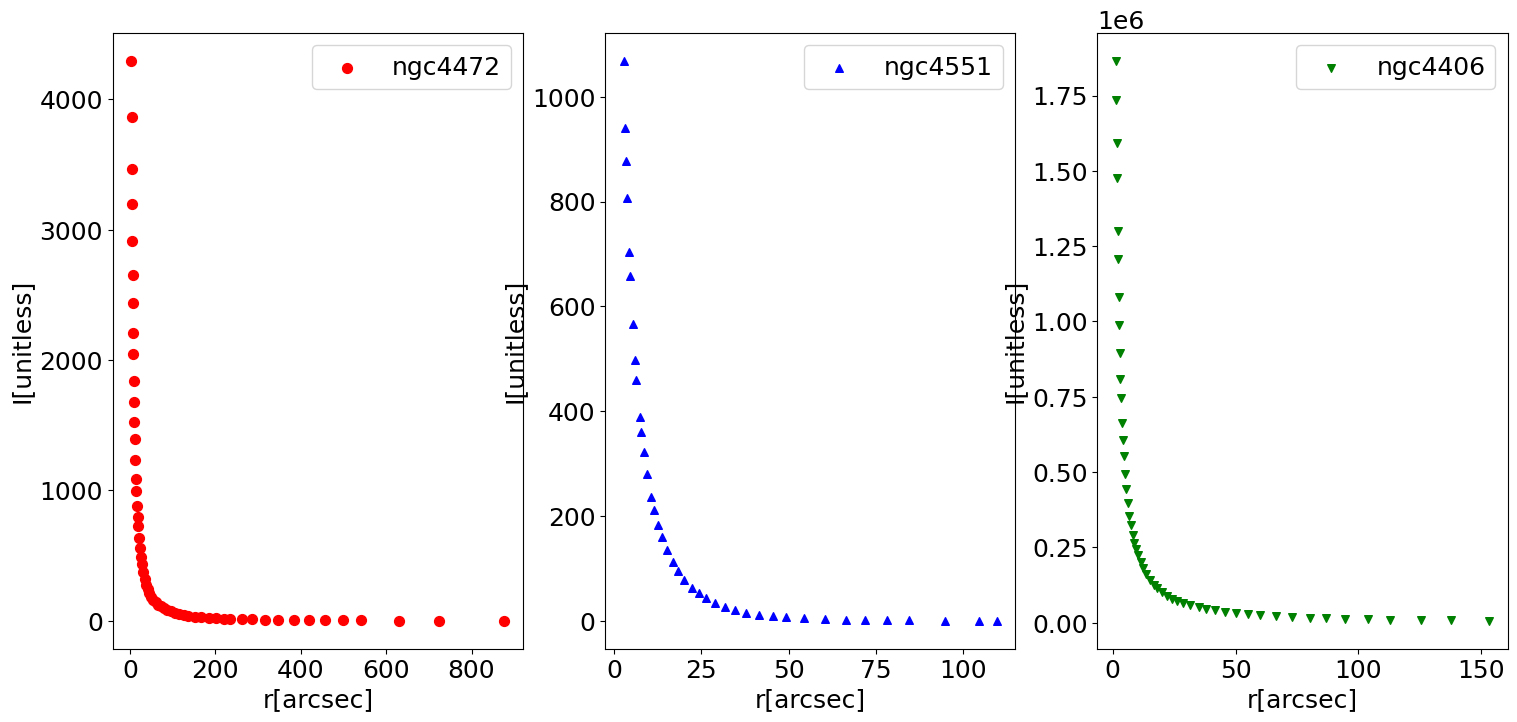

In [13]:
fig, ax = plt.subplots(1,3, figsize=(18,8))
ax[0].scatter(r1, I1, c="red", marker='o', s=50, label="ngc4472")
ax[1].scatter(r2, I2, c="blue", marker='^', s=30, label="ngc4551")
ax[2].scatter(r3, I3, c="green", marker='v', s=30, label="ngc4406")
ax[0].set_xlabel('r[arcsec]')
ax[0].set_ylabel('I[unitless]')
ax[0].legend(loc=1)
ax[1].set_xlabel('r[arcsec]')
ax[1].set_ylabel('I[unitless]')
ax[1].legend(loc=1)
ax[2].set_xlabel('r[arcsec]')
ax[2].set_xlabel('r[arcsec]')
ax[2].set_ylabel('I[unitless]')
ax[2].legend(loc=1)

plt.show()

In [14]:
k=7.669
def func1(r, I_0, r_e):
    I = I_0 * (1 + r/r_e)**(-2)
    return I
def func2(r, I_0, r_e):
    I = I_0 * np.exp(-k*((r/r_e)**(1/4)-1))
    return I
def func3(r, I_0, r_e, n):
    b = 0.868*n-0.142
    I = I_0 * np.exp(-b*((r/r_e)**(1/n)-1))
    return I


In [15]:
myModel1 = lmfit.Model(func1)
myModel2 = lmfit.Model(func2)
myModel3 = lmfit.Model(func3)

In [16]:
myModel1.set_param_hint('I_0', value=10000, min=0.0)
myModel1.set_param_hint('r_e', value=100, min=0.0)
myModel2.set_param_hint('I_0', value=10000, min=0.0)
myModel2.set_param_hint('r_e', value=100, min=0.0)
myModel3.set_param_hint('I_0', value=10000, min=0.0)
myModel3.set_param_hint('r_e', value=100, min=0.0)
myModel3.set_param_hint('n', value=16.5, min=0.5)

In [17]:
myFit11 = myModel1.fit(I1, r=r1)
myFit12 = myModel1.fit(I2, r=r2)
myFit13 = myModel1.fit(I3, r=r3)
myFit21 = myModel2.fit(I1, r=r1)
myFit22 = myModel2.fit(I2, r=r2)
myFit23 = myModel2.fit(I3, r=r3)
myFit31 = myModel3.fit(I1, r=r1)
myFit32 = myModel3.fit(I2, r=r2)
myFit33 = myModel3.fit(I3, r=r3)

In [18]:
AIC1 = np.array([myFit11.aic, myFit21.aic, myFit31.aic])
AIC2 = np.array([myFit12.aic, myFit22.aic, myFit32.aic])
AIC3 = np.array([myFit13.aic, myFit23.aic, myFit33.aic])
BIC1 = np.array([myFit11.bic, myFit21.bic, myFit31.bic])
BIC2 = np.array([myFit12.bic, myFit22.bic, myFit32.bic])
BIC3 = np.array([myFit13.bic, myFit23.bic, myFit33.bic])


deltaAIC1 = AIC1 - AIC1.min()
deltaBIC1 = BIC1 - BIC1.min()
deltaAIC2 = AIC2 - AIC2.min()
deltaBIC2 = BIC2 - BIC2.min()
deltaAIC3 = AIC3 - AIC3.min()
deltaBIC3 = BIC3 - BIC3.min()



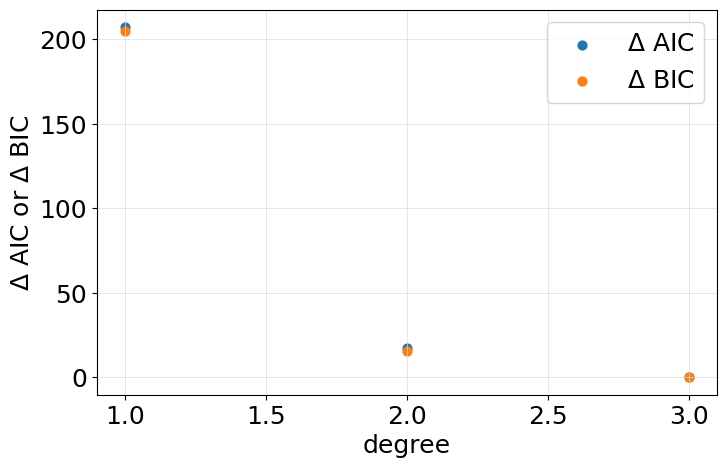

In [19]:
fig, ax = plt.subplots(1,1, figsize=(8,5))
ax.scatter(range(1,4), deltaAIC1, s=40, label=r"$\Delta$ AIC")
ax.scatter(range(1,4), deltaBIC1, s=40, label=r"$\Delta$ BIC")
ax.set_xlabel("degree")
ax.set_ylabel(r"$\Delta$ AIC or $\Delta$ BIC")
ax.legend(loc='best')
ax.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
plt.show()

In [20]:
expAIC1 = np.exp(-0.5*deltaAIC1)
print(expAIC1)
wAIC1 = expAIC1 / expAIC1.sum()
print(wAIC1)#normalized AIC weights
expBIC1 = np.exp(-0.5*deltaBIC1)
wBIC1 = expBIC1 / expBIC1.sum()
expAIC2 = np.exp(-0.5*deltaAIC2)
wAIC2 = expAIC1 / expAIC2.sum()              #normalized AIC weights
expBIC2 = np.exp(-0.5*deltaBIC2)
wBIC2 = expBIC2 / expBIC2.sum()
expAIC3 = np.exp(-0.5*deltaAIC3)
wAIC3 = expAIC3 / expAIC3.sum()              #normalized AIC weights
expBIC3 = np.exp(-0.5*deltaBIC3)
wBIC3 = expBIC3 / expBIC3.sum()

[9.90180644e-46 1.59022978e-04 1.00000000e+00]
[9.90023207e-46 1.58997693e-04 9.99841002e-01]


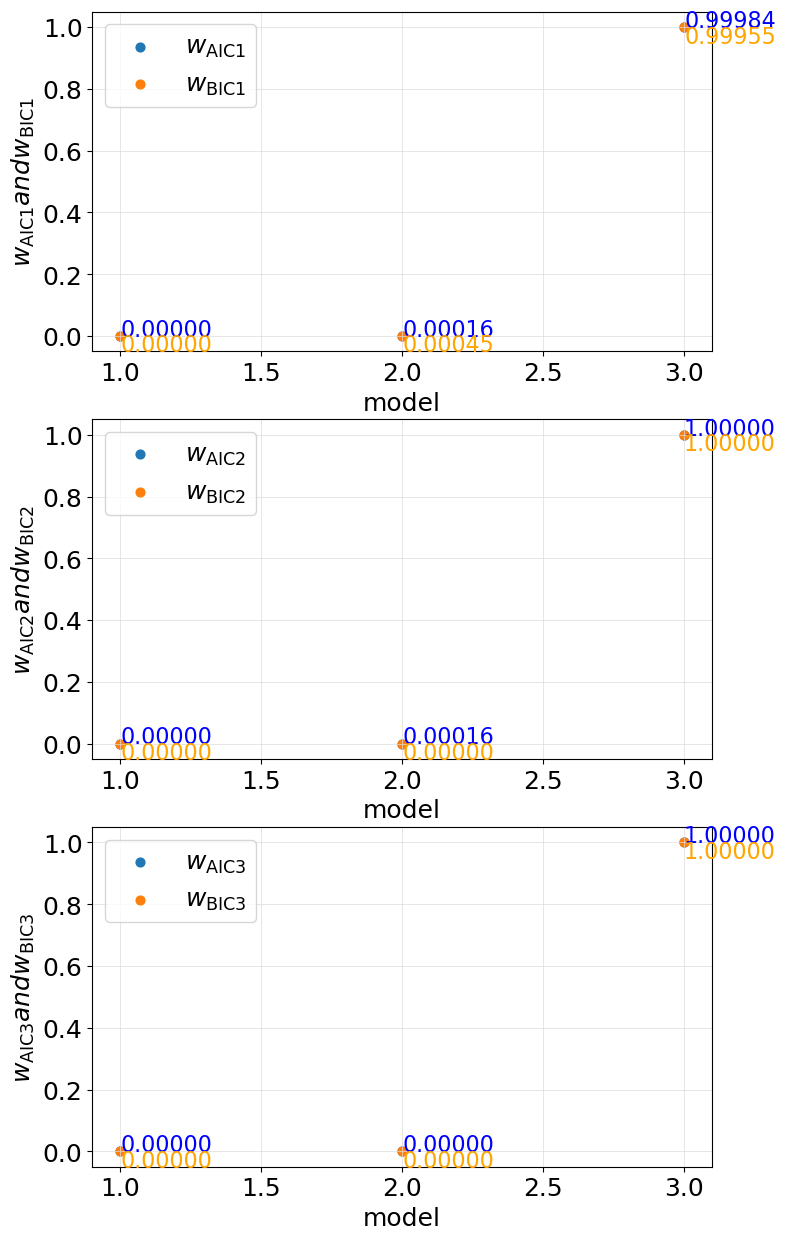

In [21]:
model = range(1,4)
fig, [ax1, ax2, ax3] = plt.subplots(3,1, figsize=(8,15))
ax1.scatter(model, wAIC1, s=40, label=r"$w_{\rm AIC1}$")
ax1.scatter(model, wBIC1, s=40, label=r"$w_{\rm BIC1}$")
for i, aic in enumerate(wAIC1):
    ax1.annotate('%0.5f' % aic, xy=(i+1, aic), color='blue')
for i, bic in enumerate(wBIC1):
    ax1.annotate('%0.5f' % bic, xy=(i+1, bic-.05), color='orange')
ax1.set_xlabel("model")
ax1.set_ylabel(r"$w_{\rm AIC1} and w_{\rm BIC1}$")
ax1.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
ax1.legend(loc='best')

ax2.scatter(model, wAIC2, s=40, label=r"$w_{\rm AIC2}$")
ax2.scatter(model, wBIC2, s=40, label=r"$w_{\rm BIC2}$")
for i, aic in enumerate(wAIC2):
    ax2.annotate('%0.5f' % aic, xy=(i+1, aic), color='blue')
for i, bic in enumerate(wBIC2):
    ax2.annotate('%0.5f' % bic, xy=(i+1, bic-.05), color='orange')
ax2.set_xlabel("model")
ax2.set_ylabel(r"$w_{\rm AIC2} and w_{\rm BIC2}$")
ax2.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
ax2.legend(loc='best')

ax3.scatter(model, wAIC3, s=40, label=r"$w_{\rm AIC3}$")
ax3.scatter(model, wBIC3, s=40, label=r"$w_{\rm BIC3}$")
for i, aic in enumerate(wAIC3):
    ax3.annotate('%0.5f' % aic, xy=(i+1, aic), color='blue')
for i, bic in enumerate(wBIC3):
    ax3.annotate('%0.5f' % bic, xy=(i+1, bic-.05), color='orange')
ax3.set_xlabel("model")
ax3.set_ylabel(r"$w_{\rm AIC3} and w_{\rm BIC3}$")
ax3.grid(True, color='gainsboro', linestyle='-', linewidth=0.5)
ax3.legend(loc='best')
plt.show()

In [22]:
wA13_1 = wAIC1[2]/wAIC1[0]   #comparing model 1 and 3 for dataset 1 in AIC
wA23_1 = wAIC1[2]/wAIC1[1]
wB13_1 = wBIC1[2]/wBIC1[0]   #comparing model 1 and 3 for dataset 1 in BIC
wB23_1 = wBIC1[2]/wBIC1[1]

wA13_2 = wAIC2[2]/wAIC2[0]   #comparing model 1 and 3 for dataset 2 in AIC
wA23_2 = wAIC2[2]/wAIC2[1]
wB13_2 = wBIC2[2]/wBIC2[0]   #comparing model 1 and 3 for dataset 2 in BIC
wB23_2 = wBIC2[2]/wBIC2[1]

wA13_3 = wAIC3[2]/wAIC3[0]   #comparing model 1 and 3 for dataset 3 in AIC
wA23_3 = wAIC3[2]/wAIC3[1]
wB13_3 = wBIC3[2]/wBIC3[0]   #comparing model 1 and 3 for dataset 3 in BIC
wB23_3 = wBIC3[2]/wBIC3[1]

print("Comparison of the third model to the other to models")
print("Dataset 1, AIC, model1", wA13_1, "model2", wA23_1, "BIC, model1", wB13_1, "model2", wB23_1)
print("Dataset 2, AIC, model1", wA13_2, "model2", wA23_2, "BIC, model1", wB13_2, "model2", wB23_2)
print("Dataset 3, AIC, model1", wA13_3, "model2", wA23_3, "BIC, model1", wB13_3, "model2", wB23_3)

Comparison of the third model to the other to models
Dataset 1, AIC, model1 1.0099167321460809e+45 model2 6288.3994178584435 BIC, model1 3.6046744868694445e+44 model2 2244.5051382236657
Dataset 2, AIC, model1 1.009916732146081e+45 model2 6288.3994178584435 BIC, model1 471178992939782.75 model2 1.7445901930114562e+21
Dataset 3, AIC, model1 1.623822166999995e+42 model2 1.4533304987431955e+30 BIC, model1 6.121125386903378e+41 model2 5.4784436326874885e+29


Above, you can see the likelihood that the third model is the best model when compared to the other two. This shows that it is several orders of magnitude more likely to be the best. For the first dataset, AIC estimates the likelihood about 3 times higher than BIC, while for the second dataset the likelihood against the second model raises significantly. For the third dataset, the likelihood is only twice as much for the AIC compared to for the BIC.

In [23]:
radius1 = np.linspace(3, 900, 3000)
fittedValues1 = myModel3.eval(r=radius1, params=myFit31.params)
radius2 = np.linspace(2, 120, 3000)
fittedValues2 = myModel3.eval(r=radius2, params=myFit32.params)
radius3 = np.linspace(1, 160, 3000)
fittedValues3 = myModel3.eval(r=radius3, params=myFit33.params)

In [24]:
deltaCI1 = myFit31.eval_uncertainty(r=radius1, sigma=2)
deltaCI2 = myFit32.eval_uncertainty(r=radius2, sigma=2)
deltaCI3 = myFit33.eval_uncertainty(r=radius3, sigma=2)

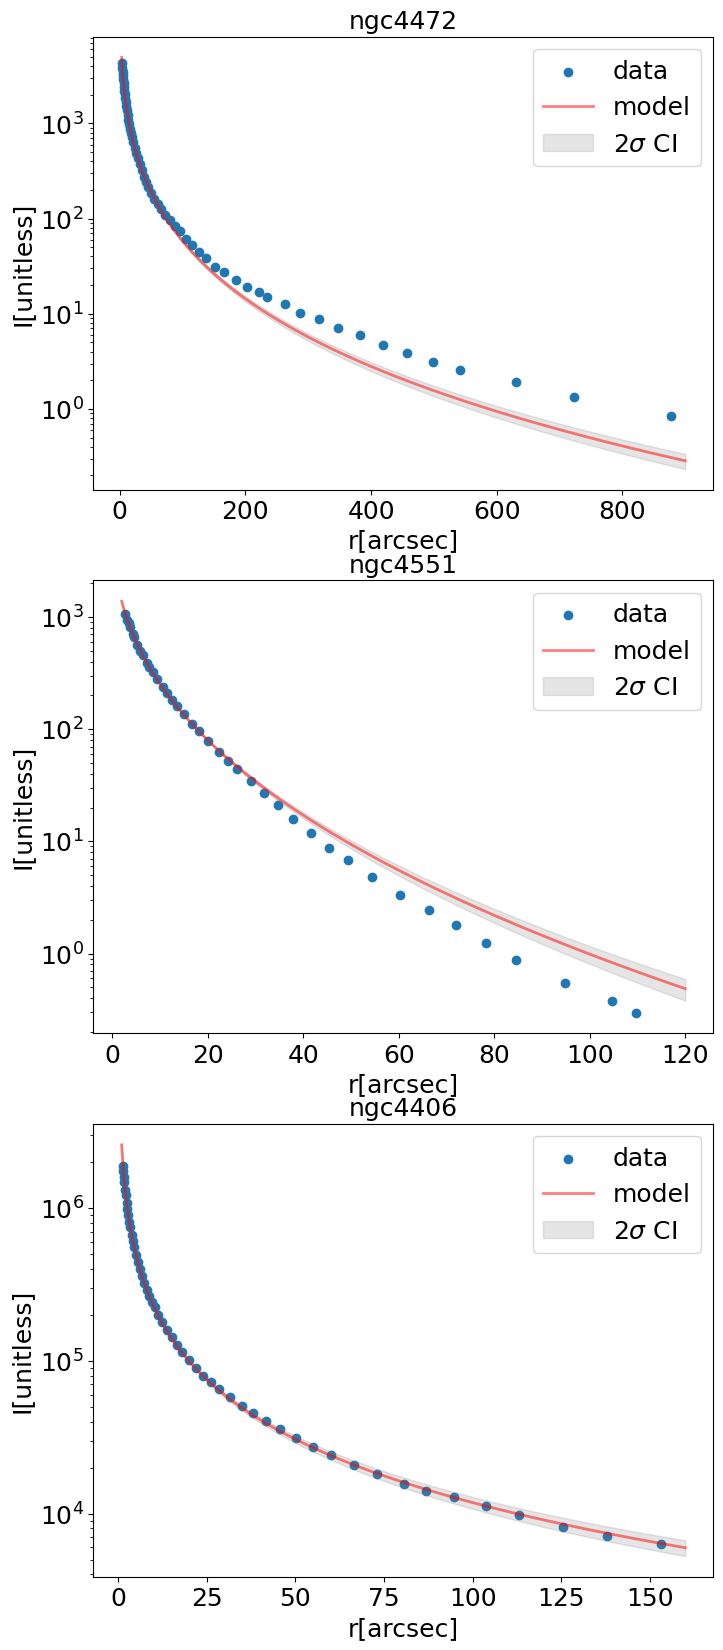

In [25]:
fig, [ax1, ax2, ax3] = plt.subplots(3,1, figsize=(8,20))

ax1.scatter(r1, I1, label = 'data')
ax1.plot(radius1, fittedValues1, c='red', linewidth=2, alpha=0.5, label='model')
ax1.fill_between(radius1, fittedValues1-deltaCI1, fittedValues1+deltaCI1, color="grey", alpha=0.2, label=r'$2\sigma$ CI')

ax2.scatter(r2, I2, label = 'data')
ax2.plot(radius2, fittedValues2, c='red', linewidth=2, alpha=0.5, label='model')
ax2.fill_between(radius2, fittedValues2-deltaCI2, fittedValues2+deltaCI2, color="grey", alpha=0.2, label=r'$2\sigma$ CI')

ax3.scatter(r3, I3, label = 'data')
ax3.plot(radius3, fittedValues3, c='red', linewidth=2, alpha=0.5, label='model')
ax3.fill_between(radius3, fittedValues3-deltaCI3, fittedValues3+deltaCI3, color="grey", alpha=0.2, label=r'$2\sigma$ CI')

ax1.set_xlabel('r[arcsec]')
ax1.set_ylabel('I[unitless]')
ax1.set_title("ngc4472")
ax1.set_yscale('log')
ax1.legend(loc=1)

ax2.set_xlabel('r[arcsec]')
ax2.set_ylabel('I[unitless]')
ax2.set_title("ngc4551")
ax2.set_yscale('log')
ax2.legend(loc=1)

ax3.set_xlabel('r[arcsec]')
ax3.set_ylabel('I[unitless]')
ax3.set_title("ngc4406")
ax3.set_yscale('log')
ax3.legend(loc=1)


In [26]:
print(myFit31.fit_report())
print(myFit32.fit_report())
print(myFit33.fit_report())

[[Model]]
    Model(func3)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 60
    # data points      = 58
    # variables        = 3
    chi-square         = 2846.26315
    reduced chi-square = 51.7502391
    Akaike info crit   = 231.812515
    Bayesian info crit = 237.993844
    R-squared          = 0.99995957
[[Variables]]
    I_0:  4645.32917 +/- 61.5430565 (1.32%) (init = 10000)
    r_e:  3.23478159 +/- 0.04667326 (1.44%) (init = 100)
    n:    4.30139604 +/- 0.06807062 (1.58%) (init = 16.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(I_0, r_e) = -0.9983
    C(r_e, n)   = -0.8913
    C(I_0, n)   = +0.8800
[[Model]]
    Model(func3)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 140
    # data points      = 40
    # variables        = 3
    chi-square         = 355.948658
    reduced chi-square = 9.62023400
    Akaike info crit   = 93.4362819
    Bayesian info crit = 98.5029203
    R-squared          = 0.999

In [27]:
print(myFit31.ci_report(sigmas=[2], with_offset=False))
print(myFit32.ci_report(sigmas=[2], with_offset=False))
print(myFit33.ci_report(sigmas=[2], with_offset=False))

        95.45%    _BEST_    95.45%
 I_0:4524.051574645.329174777.08968
 r_e:   3.13784   3.23478   3.32949
 n  :   4.16497   4.30140   4.44604
        95.45%    _BEST_    95.45%
 I_0:1131.212041167.259181207.25952
 r_e:   2.40001   2.48620   2.56966
 n  :   2.31491   2.41224   2.51686
        95.45%    _BEST_    95.45%
 I_0:6049269.318937908746.8945111206421.93474
 r_e:   0.20100   0.28953   0.38352
 n  :  10.16576  11.56653  13.39100


For the three datasets respectively, the 2$\sigma$ individual confidence intervals of $r_e$ or [3.14, 3.33], [2.40, 2.57] and [0.20, 0.38], and of n are [4.16, 4.45], [2.31, 2.52] and [10.2, 13.4].

In [28]:
def S1(I, r, I_0, r_e, n):
    cost = 0.0
    for i in range(len(r)):
        cost += I[i] - func3(r[i], I_0, r_e, n)
    return cost
bestr_e = myFit31.best_values['r_e']
bestn = myFit31.best_values['n']
bestI_0 = myFit31.best_values['I_0']
bestS1 = S1(I1, r1, bestI_0, bestr_e, bestn)
print("Minimum of the cost function: ", bestS1)

Minimum of the cost function:  90.33738051755002


In [29]:
N = len(r1)
K = 2
Fdistrib = sp.stats.f(K, N-K)
contourLevel95 = bestS1 * (1+K/(N-K)*Fdistrib.ppf(1-0.05))
print("Contour level of the 95% confidence region: ", contourLevel95)

Contour level of the 95% confidence region:  100.53860391749329


In [30]:
theta1 = np.linspace(0.2, 100.0, 500)
theta2 = np.linspace(0.2, 50.0, 500)
Theta1, Theta2 = np.meshgrid(theta1, theta2)
z1 = S1(r1, I1, bestI_0,Theta1, Theta2)

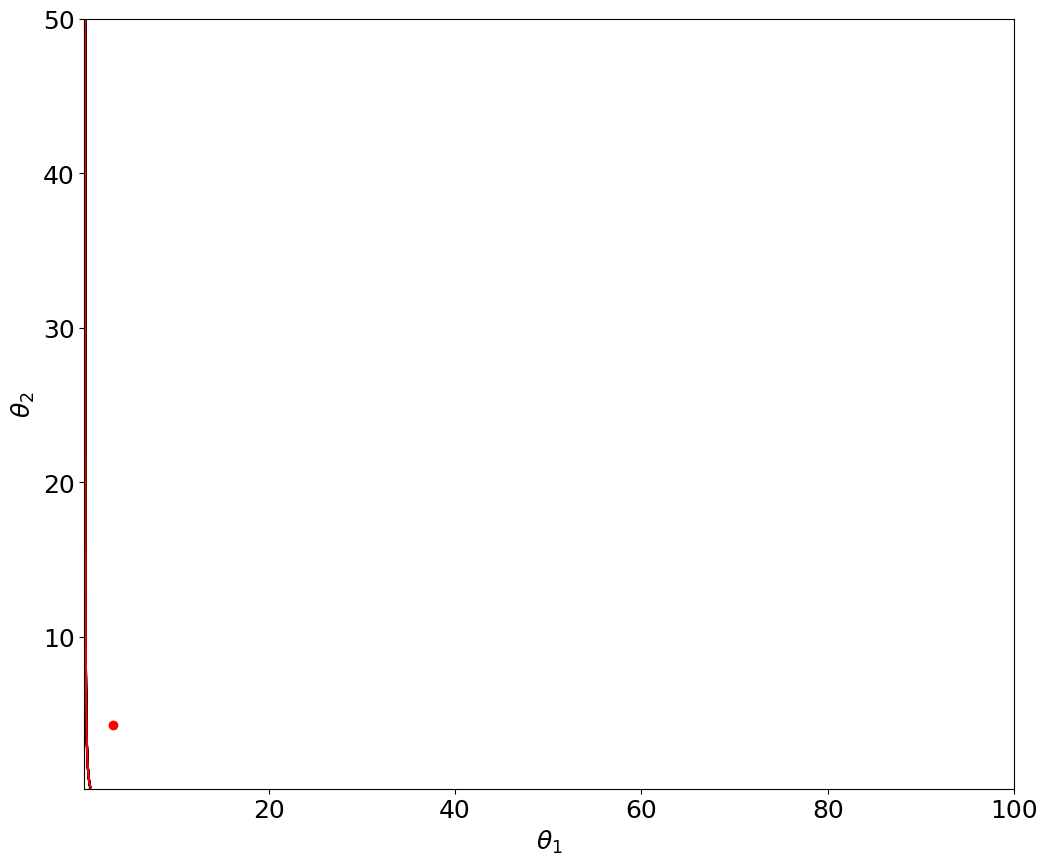

In [31]:
fig, ax = plt.subplots(1,1, figsize=(12,10))

levels =[0.075, 0.2, 0.5, 1., 5., 10, 20, 30, 40, 50, 100, 200, 300]
contours = ax.contour(Theta1, Theta2, z1, levels=levels, colors="black")
contours = ax.contour(Theta1, Theta2, z1, levels=[contourLevel95], colors="red")

ax.scatter([bestr_e], [bestn], c="red")

ax.tick_params(axis='both', which='major')
#ax.set_ylim(0, 50)
ax.set_xlabel(r'$\theta_1$')
ax.set_ylabel(r'$\theta_2$')
plt.show()

---

## Task 3: Supernovae

A supernova is a violent explosion of a star which makes it temporarily so luminous that it can be seen from huge distances.

In [68]:
Image(url="https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Images/supernovaNGC2525.jpg", width=700)

The picture above shows the spiral galaxy NGC2525, in which a supernova was detected on 15 January 2018. The supernova is the blueish star at the left of the image. Although NGC2525 is located at a distance of 70 million lightyears, the supernova is brighter than any of the foreground stars in our own Milky Way. Image credit: NASA. 

Different types of supernova exist, and this exercise is about Type Ia supernovae, which are the result from a gigantic thermonuclear detonation of a white dwarf star that accreted mass from a neighboring star. A theoretical analysis suggests that all Type Ia supernovae have more or less the same intrinsic brightness. Or, in other words, the apparent brightness together with the expected intrinsic brightness can be used to derive the distance of the supernova, and thus of its host galaxy.

The dataset below is a semi-realistic collection of distances of a $N=100$ synthetic supernova. In practice, astronomers usually work with the distance modulus $\mu$ rather than the actual distance $d$ in parsecs:

$$\mu=5\log_{10}(d)-5$$

but this is not of importance for the remainder of the exercise. The distance moduli are listed as a function of the redshift $z$ of the supernova: the relative shift in wavelength of its spectral lines: 
$$ z = \frac{\lambda_{obs} - \lambda_{emit}}{\lambda_{emit}} $$
because the host galaxy is moving away from us due to the expansion of the universe:

In [69]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/supernova.csv"
data = pd.read_csv(url)

In [70]:
data.head()

,z,mu,sigma
0,0.072804,37.957583,0.621841
1,0.108690,39.052648,0.632607
2,0.174180,40.422952,0.652254
3,0.206391,41.090266,0.661917
4,0.212883,40.380070,0.663865


The columns in the table are:
- **z**: the redshift of the supernova
- **mu**: the distance modulus [mag]
- **sigma**: the uncertainty on the distance modulus [mag]

<>:4: SyntaxWarning:

invalid escape sequence '\m'

<>:4: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_485651/2616506484.py:4: SyntaxWarning:

invalid escape sequence '\m'



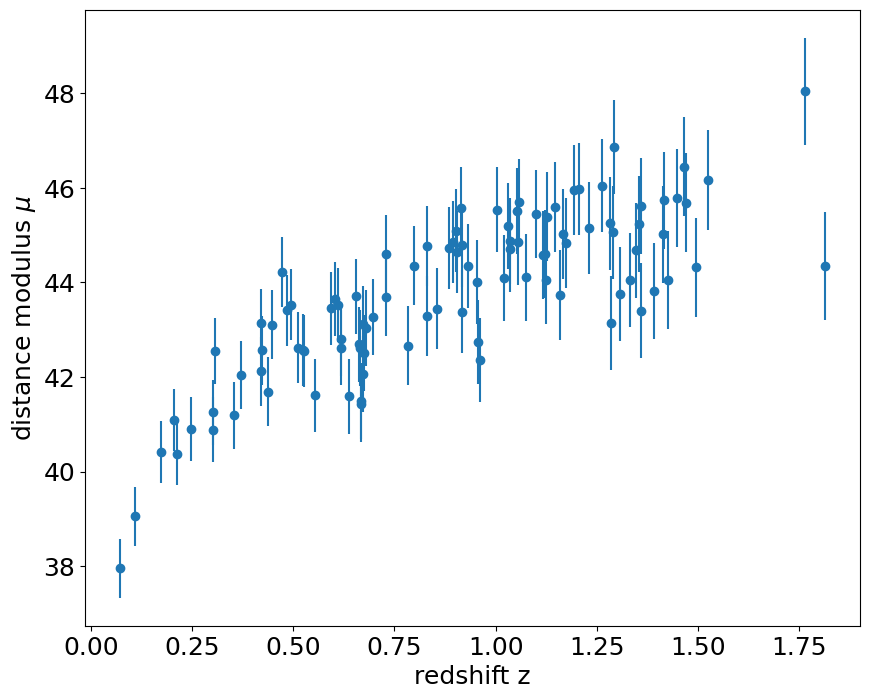

In [71]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
ax.errorbar(data['z'], data['mu'], yerr=data['sigma'], fmt='o')
ax.set_xlabel('redshift z')
ax.set_ylabel('distance modulus $\mu$') 
plt.show()

It would be very useful to have an empirical relation that can be used to predict the distance (or distance modulus) of the supernova given the easily measurable redshift. One possible option is to simply fit a polynomial model

$ \mu(z_n) = \theta_0 + \sum_{k=1}^K \theta_k \ z_n^k + \varepsilon_n $

to the data, and use this model to predict the distance modulus for future supernovae. This will **not** be done in this exercise. Instead of using $x^k$ as base functions, we will be using gaussian base functions:

$ \mu(z_n) = \theta_0 + \sum_{k=1}^K \theta_k e^{-\frac{(z_n - x_k)^2}{2 h^2}} + \varepsilon_n $

This type of regression is called a *gaussian basis function regression*. Here $(z_n, \mu_n=\mu(z_n))$ are the observations.

Your tasks are:
- Fit a model with $K=100$ gaussian basis functions, each with a standard deviation $h=0.14$, and a mean $x_k$ given by the dense grid `x = np.linspace(0.05, 1.85, K)`. 
- Visualize your fit, and plot the fit coefficients $\theta_k$ as a function of $k \in \{1,..,K\}$. Explain what you see.
- Redo the fit with the same model using Ridge and Lasso regression, where you determine in both cases the regularization parameter $\lambda$ using 10-fold cross-validation. 
- Visualize the Ridge and the Lasso fits, and plot again the fit coefficients. Compare their magnitude with the regular fit coefficients.

Another alternative to create an empirical is **kernel regression**, sometimes also called **Nadaraya-Watson regression**. Kernel regression is a non-parametric approach, that does not involve fitting model parameters. As a kernel we will choose a Gaussian kernel, which leads to the following model:

$$ \mu(z_{\rm new}) = \frac{\displaystyle\sum_{n=1}^N \mu_n e^{-\frac{(z_{\rm new} - z_n)^2}{2 h^2}}}{\sum_{n=1}^N e^{-\frac{(z_{\rm new} - z_n)^2}{2 h^2}} } $$

where $(z_n, \mu_n)$ are the observed data. As you can see, this model estimates the distance modulus $\mu$ at an arbitrary value $z_{\rm new}$ by computing a weighted average over all observed $\mu_n$ values. Those $\mu_n$ values that have a corresponding $z_n$ value closer to the requested $z_{\rm new}$ value get a larger weight.

- Compute and plot an empirical relationship between $\mu$ and $z$ using gaussian kernel regression, where you determine an optimal value for $h$ using 10-fold cross-validation. For visualization you can use $z_{\rm new}$ = `np.linspace(0.05, 1.85, 100)`. Compare your result with the one obtained with regularized regression.

---

---

In [72]:
z = data['z'].values
mu = data['mu'].values
sigma = data['sigma'].values

# Gaussian basis function parameters
K = 100
h = 0.14
x_k = np.linspace(0.05, 1.85, K)  # centers of the K bumps

# Build design matrix: shape (N, K+1)
# Column 0: the intercept (theta_0), all ones
# Columns 1..K: the K Gaussian bumps evaluated at each z_n
N = len(z)
Phi = np.zeros((N, K + 1))
Phi[:, 0] = 1.0  # intercept column

for k in range(K):
    Phi[:, k + 1] = np.exp(-((z - x_k[k])**2) / (2 * h**2))

In [73]:
#WLS fit
weights = 1.0 / sigma**2
wls_model = sm.WLS(mu, Phi, weights=weights)
result = wls_model.fit()

theta = result.params  # shape (K+1,): theta_0 then theta_1..theta_K

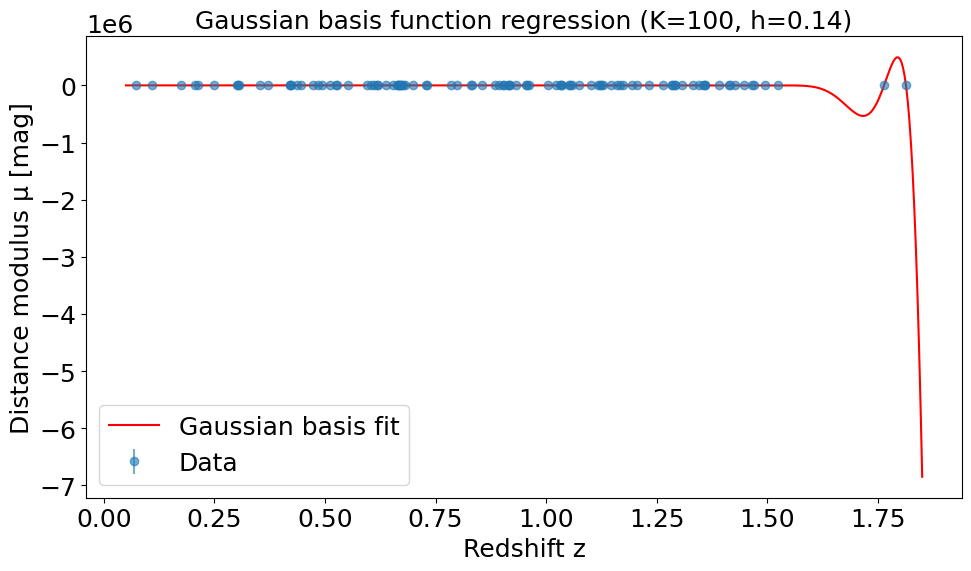

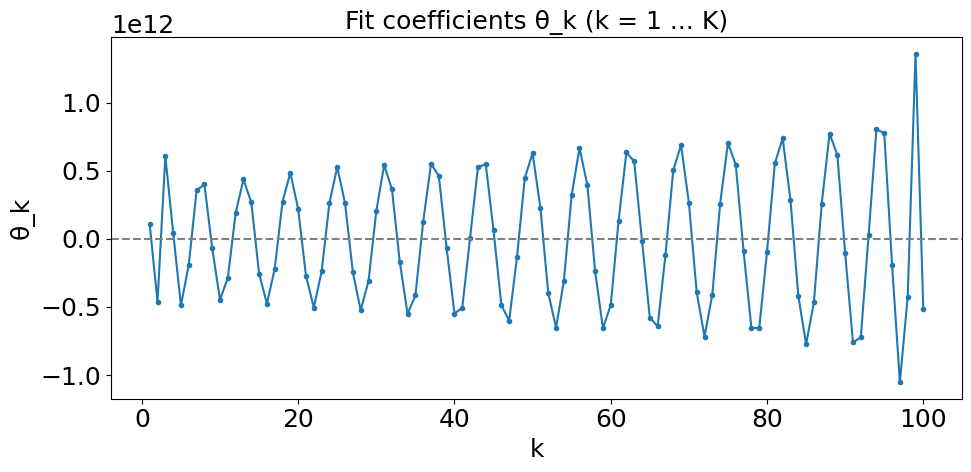

In [74]:
# Predict on a fine grid for smooth curve
z_grid = np.linspace(0.05, 1.85, 500)
Phi_grid = np.zeros((500, K + 1))
Phi_grid[:, 0] = 1.0
for k in range(K):
    Phi_grid[:, k + 1] = np.exp(-((z_grid - x_k[k])**2) / (2 * h**2))

mu_pred = Phi_grid @ theta

# Plot 1: data + fit
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(z, mu, yerr=sigma, fmt='o', label='Data', alpha=0.6)
ax.plot(z_grid, mu_pred, color='red', label='Gaussian basis fit')
ax.set_xlabel('Redshift z')
ax.set_ylabel('Distance modulus μ [mag]')
ax.set_title('Gaussian basis function regression (K=100, h=0.14)')
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: coefficients theta_1 .. theta_K
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(1, K + 1), theta[1:], marker='o', markersize=3)
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('k')
ax.set_ylabel('θ_k')
ax.set_title('Fit coefficients θ_k (k = 1 ... K)')
plt.tight_layout()
plt.show()